# Classification with XGBoost


In [1]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

## Load, clean train

In [2]:
# Load and clean dataset
data = pd.read_csv('data/bcn_noise_class_ml_dataset.csv')


In [3]:
# Clean dataset
data_clean = data.dropna()
data_clean.reset_index(inplace=True, drop = True)

In [4]:
# Feature engineering (combine width and betweenness centrality, create new features based on distances)
#data['width_x_betw'] = data['width'] * data['betw_centrality']
#data['min_arterial_dist'] = data[['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']].min(axis=1)
#data['min_local_road_dist'] = data[['dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street']].min(axis=1)

In [5]:
X = data_clean.drop(columns=['road_id','noise_day','noise_evening', 'noise_night']) 

In [6]:
# No need for encoding since all features are numerical
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = np.asarray(data_clean["noise_day"])

# Splitting
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y, data_clean, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)


(10283, 18)
(10283,)
(2571, 18)


## TrainXGBoost

In [7]:
# Train XGBoost model
model = xgb.XGBClassifier()

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))


[0.72630044 0.72386971 0.72241128 0.73054475 0.72373541]
0.9717008655061753
0.7405678724231817


### ExAI

Dependance Scatter plots

**What the Plot Shows**
This is a dependence scatter plot:
X-axis: The actual feature value, e.g., the distance to trunk.
Y-axis: The SHAP value for that feature.
Each dot is an individual prediction/sample.

**Interpreting the Trend**
If the points form a downward slope, it indicates a negative (inverse) relationship:
If the points slope upward, it indicates a positive relationship:
SHAP values are additive contributions to the logit (log-odds), so the trend can be interpreted as a directional influence.

The Grey Histogram at the Bottom is a marginal histogram of the feature's value in the test set. It gives context for where the model sees more or fewer examples—useful for judging how confident you should be about the observed trend.


['road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


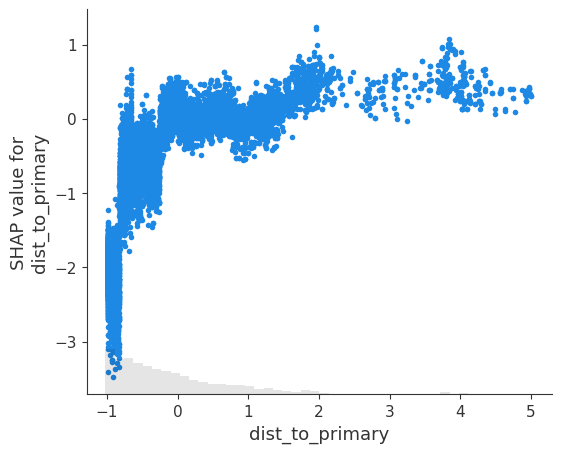

In [8]:
# Create DataFrames with column names
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Refit model with DataFrames
model.fit(X_train_df, y_train)

# SHAP explanation (using TreeExplainer for tree-based models instead of LinearExplainer)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_df)

# Visualise
print(shap_values.feature_names)

# Select class 0 (or whichever class you want to inspect)
shap.plots.scatter(shap_values[:, 2, 1])  # [:, feature, class]


### Waterfall plots

A SHAP waterfall chart explains how the features of a single instance contribute to a specific model output (in classification: the log-odds or probability for one class). 

It's useful for understand the misclassified elements and what signal has been picked up for the specific data point.

data structure: (samples, classes, features)


**How to Read the Chart**
Base value (at the bottom):
The expected model output (log-odds) for class 0 over the entire dataset — the baseline prediction if no features were known.
Feature bars (middle):
Each feature either increases (red bars) or decreases (blue bars) the model’s output for class 0 relative to the base value.
Final value (at the top):
The model’s predicted log-odds for class 0 for this instance.


You’re seeing exactly why the model believed a point should (or shouldn’t) belong to a certain class, and which features drove that decision.














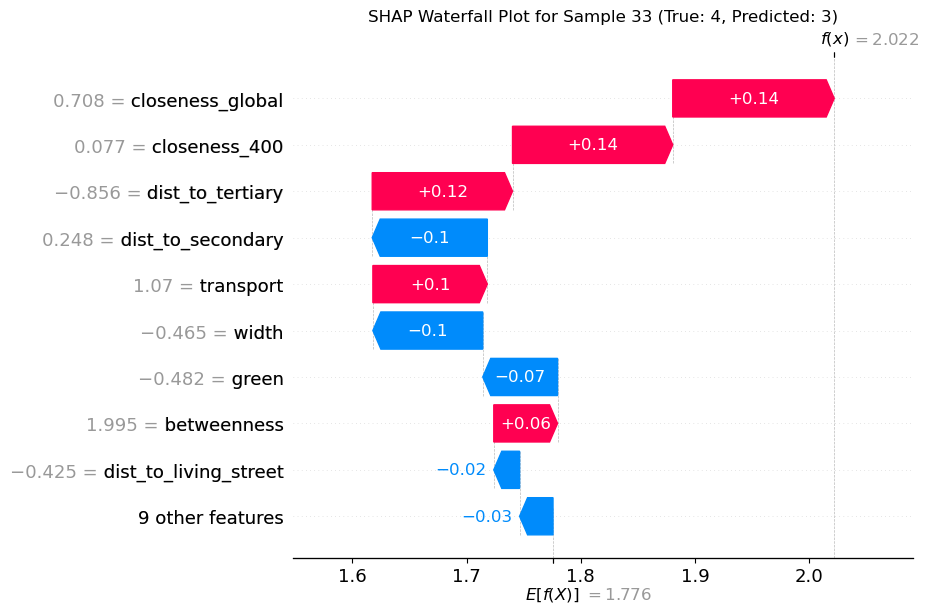

In [9]:
y_pred = model.predict(X_test_df)
shap_values_test = explainer(X_test_df)

idx = np.where((y_test == 4) & (y_pred == 3))[0][1]
  
shap.plots.waterfall(shap_values_test[idx, :, 3], show=False) #  [sampleID][:, label]
plt.title(f"SHAP Waterfall Plot for Sample {idx} (True: {y_test[idx]}, Predicted: {y_pred[idx]})")
plt.show()

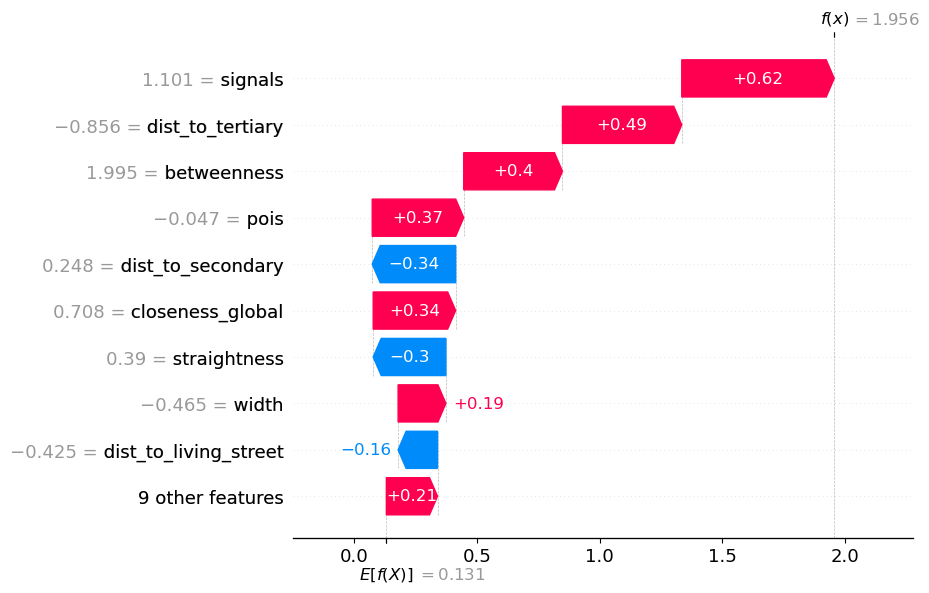

In [10]:
shap.plots.waterfall(shap_values_test[idx, :, 4]) 

### Summary plot

The SHAP summary plot is a compact visualisation that summarises global feature importance and the distribution of feature effects across your dataset.

Relationship between each of the features and the classes.

What the Bar Plot Shows
Each bar corresponds to a feature.

Bar length represents the mean absolute SHAP value for that feature across all samples.

This is a measure of overall feature importance: how much that feature contributes, on average, to the model’s output magnitude (regardless of direction).

It's the most useful plot when trying to get an overall understanding of the model and the signal that it's understanding from the different features.





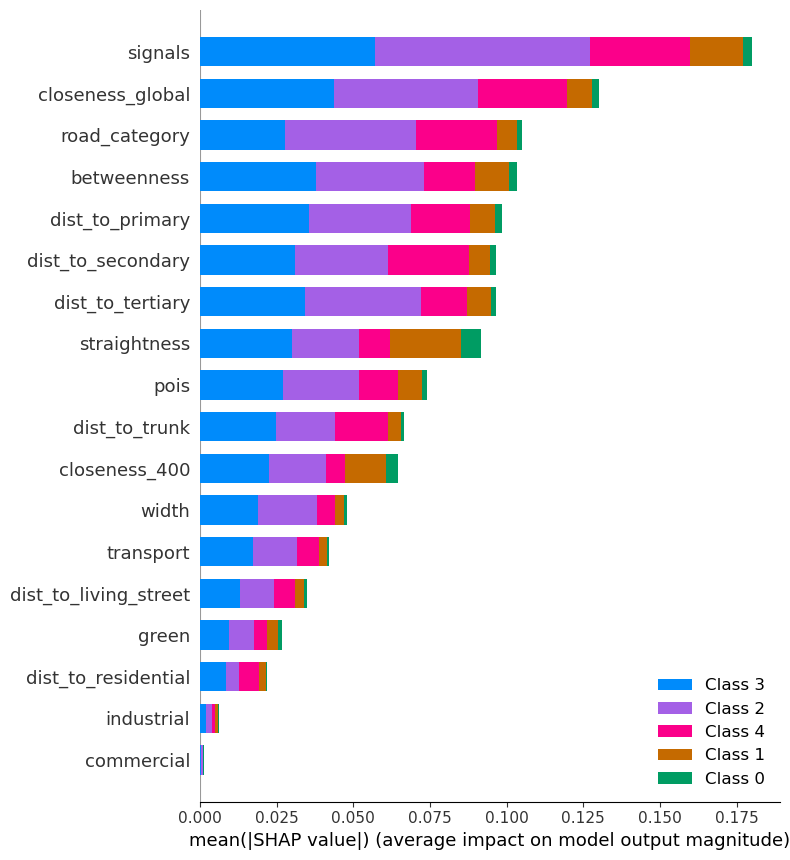

In [27]:
shap.summary_plot(shap_values, X_train_df)

## Train RandomForest

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42,
    max_depth=None,         
    min_samples_leaf=1,    
    min_samples_split=2,   
)

# Create DataFrames with column names
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

scores = cross_val_score(model, X_train_df, y_train, cv = 5)
print(scores)

model.fit(X_train_df, y_train)
print(model.score(X_train_df, y_train))
print(model.score(X_test_df, y_test))

[0.73748177 0.72289742 0.73602333 0.73832685 0.73151751]
0.9984440338422639
0.7487359004278491


In [13]:
# SHAP explanation (using TreeExplainer for tree-based models instead of LinearExplainer)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_df.iloc[:100, :])

# Visualise
print(shap_values.feature_names)

['road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


### Waterfall plot

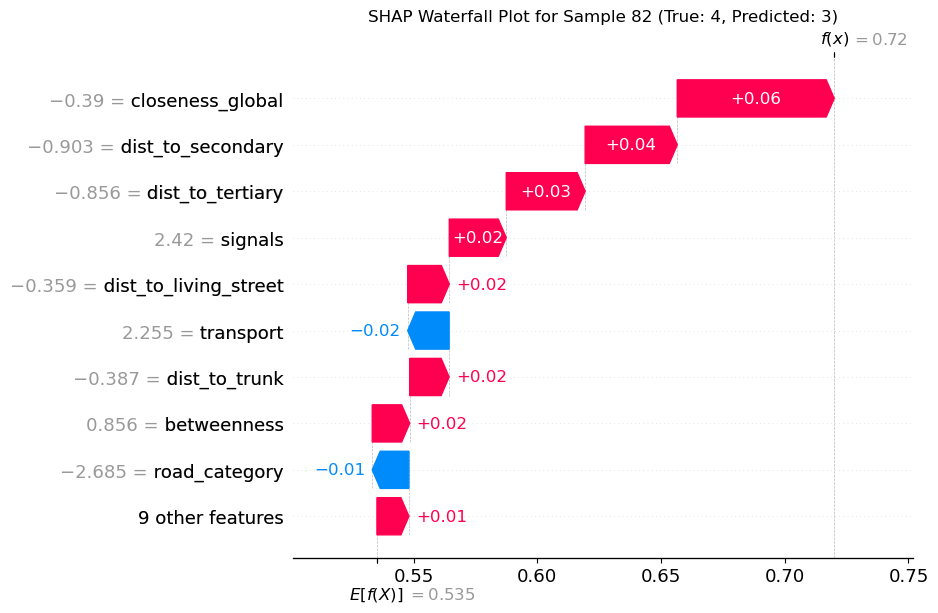

In [34]:
y_pred = model.predict(X_test_df)
shap_values_test = explainer(X_test_df)

idx = np.where((y_test == 4) & (y_pred == 3))[0][5]
  
shap.plots.waterfall(shap_values_test[idx, :, 3], show=False) #  [sampleID][:, label]
plt.title(f"SHAP Waterfall Plot for Sample {idx} (True: {y_test[idx]}, Predicted: {y_pred[idx]})")
plt.show()

### Summary plot

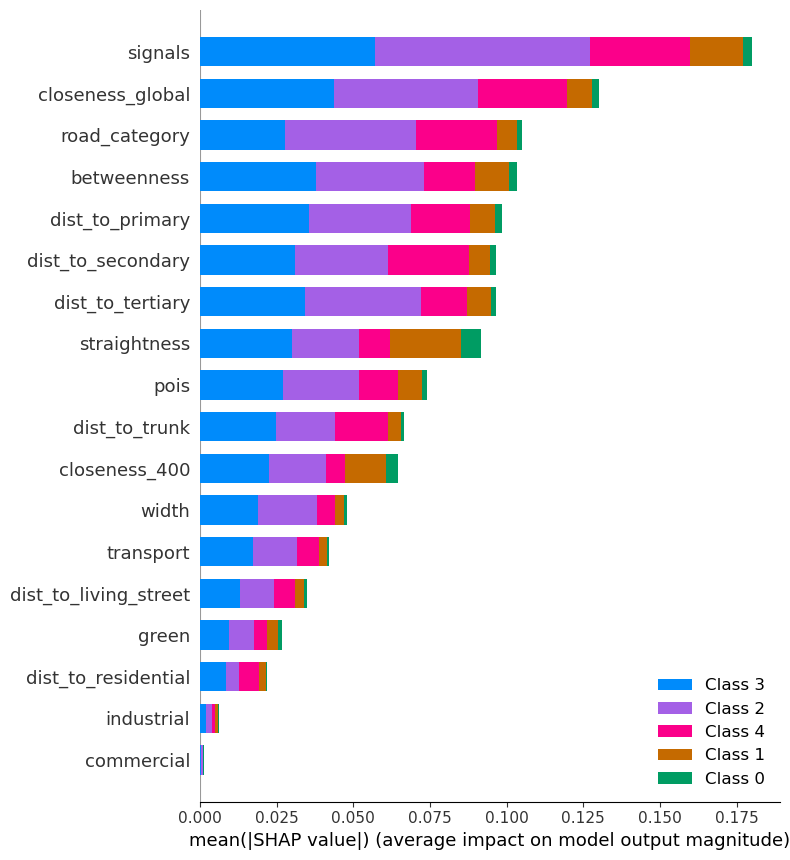

In [15]:
shap.summary_plot(shap_values, X_train_df)